# Large-scale optimization using decomposition

## Lecture 5 exercises: progressive hedging (student skeleton)

This notebook contains the **data and scenario-tree objects** needed for all exercises.
Your task is to implement:

1. Deterministic equivalent
2. NAC formulation and augmented Lagrangian subproblem
3. Two-stage progressive hedging
4. Sensitivity to the penalty parameter $\rho$
5. Three-stage progressive hedging

Refer to the exercise sheet for the full problem description and questions.

In [4]:
using JuMP
using Gurobi
# Set reusable Gurobi environment
const GRB_ENV = Gurobi.Env()
Gurobi_constructor = ()->Gurobi.Optimizer(GRB_ENV)
using Plots
using Printf

Set parameter Username
Set parameter LicenseID to value 2773792
Academic license - for non-commercial use only - expires 2027-02-02


## Data


In [14]:
# Sets
T  = 1:4           # operating periods
S  = 1:6           # scenarios
P  = fill(1/6, 6)  # equal probabilities

# Demand matrix d[t,s]  (rows = periods, columns = scenarios)
d = [  3   3   3   3   3   3     # period 1: all low (charging opportunity)
       3   3   3  20  20  20     # period 2: node signal (low vs high)
       5  15  10  25  35  30     # period 3: within-node variation
      15   5  10  35  25  30 ]   # period 4: within-node variation

# Cost parameters
c_inv = 10.0   # storage investment cost [$/MWh capacity]
c_chg =  5.0   # charging cost [$/MWh]
c_bak = 300.0  # backup generation cost [$/MWh]
c_bar = 15.0   # max charge rate [MWh/period]
e0    =  0.0   # initial stored energy [MWh]
c2    = 18.0;  # stage-2 additional capacity cost — used in Question 5

## Question 1 — Deterministic equivalent

Formulate and solve the deterministic equivalent of the two-stage problem. Report the optimal storage capacity $x^*$ and objective value. Verify that the second-stage constraints are satisfied for every scenario at the optimal solution.

**Tip:** There is a single first-stage variable $x$ shared across all scenarios. Second-stage variables are indexed by $(t, s)$.

In [15]:
m_ref = Model(Gurobi_constructor)
set_silent(m_ref)

# TODO: define the first-stage variable x_ref >= 0
@variable(m_ref, x_ref >= 0)

# TODO: define the second-stage variables (all >= 0, indexed over T and S)
#   cc[T, S]  — energy charged into storage
@variable(m_ref, cc[T,S] >= 0)
#   u[T, S]   — energy discharged from storage
@variable(m_ref, u[T,S] >= 0)
#   e[T, S]   — stored energy at end of period
@variable(m_ref, e[T,S] >= 0)
#   y[T, S]   — backup generation
@variable(m_ref, y[T,S] >= 0)

# TODO: write the objective
#   Minimise:  c_inv * x_ref  +  sum_{s,t} P[s] * (c_chg*cc[t,s] + c_bak*y[t,s])
@objective(m_ref, Min, c_inv*x_ref + sum(P[s] * (c_chg*cc[t,s] + c_bak*y[t,s]) for s in S, t in T))


# TODO: energy balance constraints
#   Period 1:  e[1,s] == e0 + cc[1,s] - u[1,s]          for all s
@constraint(m_ref, [s=S], e[1,s] == e0 + cc[1,s] - u[1,s])
#   Period t>1: e[t,s] == e[t-1,s] + cc[t,s] - u[t,s]  for all t, s
@constraint(m_ref, [t=T,s=S; t > 1], e[t,s] == e[t-1,s] + cc[t,s] - u[t,s])
# TODO: storage capacity constraints:  e[t,s] <= x_ref   for all t, s
@constraint(m_ref, [t=T,s=S], e[t,s] <= x_ref)
# TODO: charge rate constraints:       cc[t,s] <= c_bar  for all t, s
@constraint(m_ref, [t=T,s=S], cc[t,s] <= c_bar)
# TODO: demand satisfaction:           u[t,s] + y[t,s] >= d[t,s]  for all t, s
@constraint(m_ref, [t=T,s=S], u[t,s] + y[t,s] >= d[t,s])

optimize!(m_ref)

# TODO: extract x_opt and obj_opt, print them
println("x* = $(value(x_ref)), optimal objective value = $(objective_value(m_ref))")
# TODO: print per-scenario total backup [MWh] to verify demand is met in every scenario
for s in S
    y_sum = sum(value(y[t,s]) for t in T)
    println("Scenario $s: $y_sum")
end


x* = 12.0, optimal objective value = 3785.0
Scenario 1: 0.0
Scenario 2: 0.0
Scenario 3: 0.0
Scenario 4: 23.0
Scenario 5: 23.0
Scenario 6: 23.0


## Question 2 — NAC formulation and augmented Lagrangian subproblem

Introduce a scenario copy $x_s$ of the capacity variable for each $s \in S$ and enforce nonanticipativity via the agreement variable $z$ and constraints $x_s = z$.

Write the augmented Lagrangian subproblem for scenario $s$ and implement it as a function.

Recall that the augmented Lagrangian adds a dual term $\lambda_s(x_s - z)$ and a quadratic penalty $\frac{\rho}{2}(x_s - z)^2$ to the original objective for scenario $s$. With $x_s$ as a free variable this becomes a QP, which Gurobi handles directly.

**Tip:** Write the augmented Lagrangian objective by hand before translating it to code.

In [27]:
function solve_subproblem(s, lam1s, z1, rho)
    m = Model(Gurobi_constructor)
    set_silent(m)

    # First-stage capacity copy for this scenario
    @variable(m, x1 >= 0)
    # Dispatch variables for scenario s (period-indexed only)
    @variable(m, cvar[T] >= 0)  # charge
    @variable(m, u[T]    >= 0)  # discharge
    @variable(m, e[T]    >= 0)  # stored energy
    @variable(m, y[T]    >= 0)  # backup

    # TODO: write the augmented Lagrangian objective
    #   = investment cost for x1
    #   + dual coupling term:      lam1s * x1  (the constant -lam1s*z1 can be dropped)
    #   + quadratic penalty term:  (rho/2) * (x1 - z1)^2
    #   + dispatch cost for scenario s:  sum_t (c_chg*cvar[t] + c_bak*y[t])
    @objective(m, Min, c_inv*x1 + lam1s*x1 + (rho/2)*(x1-z1)^2 + sum(c_chg*cvar[t] + c_bak*y[t] for t in T) )

    # TODO: energy balance constraints (same structure as Q1, scenario s only)
    #   Period 1:  e[1,s] == e0 + cc[1,s] - u[1,s]          for all s
    @constraint(m, e[1] == e0 + cvar[1] - u[1])
    #   Period t>1: e[t,s] == e[t-1,s] + cc[t,s] - u[t,s]  for all t, s
    @constraint(m, [t=T; t > 1], e[t] == e[t-1] + cvar[t] - u[t])

    # TODO: storage capacity, charge rate, and demand constraints
    # TODO: storage capacity constraints:  e[t,s] <= x_ref   for all t, s
    @constraint(m, [t=T], e[t] <= x1)
    # TODO: charge rate constraints:       cc[t,s] <= c_bar  for all t, s
    @constraint(m, [t=T], cvar[t] <= c_bar)
    # TODO: demand satisfaction:           u[t,s] + y[t,s] >= d[t,s]  for all t, s
    @constraint(m, [t=T], u[t] + y[t] >= d[t,s])


    optimize!(m)
    return value(x1)
end

solve_subproblem (generic function with 1 method)

## Question 3 — Two-stage progressive hedging

Implement progressive hedging with $\rho = 8$. Initialise $\lambda_s^0 = 0$ and $z^0 = 0$ for all $s$.

At each iteration $k$:
1. **x-update**: solve each per-scenario subproblem to get $x_s^{k+1}$;
2. **z-update**: $z^{k+1} = \sum_s P_s\, x_s^{k+1}$;
3. **$\lambda$-update**: $\lambda_s^{k+1} = \lambda_s^k + \rho(x_s^{k+1} - z^{k+1})$.

Run for 25 iterations, reporting $z^k$ and the primal/dual squared residuals at each step.
Verify that the final $z$ matches $x^*$ from Question 1.

In [28]:
function run_PH_2stage(rho_val; n_iter=25, verbose=true)

    # TODO: initialise multipliers lam (vector of zeros, one per scenario)
    lam = zeros(length(S))
    # TODO: initialise agreement variable z = 0.0
    z = 0.0
    # TODO: initialise scenario solution vector xs (zeros)
    xs = zeros(length(S))
    # TODO: initialise empty vectors r_prim and r_dual to store residuals
    r_prim = []
    r_dual = []

    if verbose
        println("ρ = $rho_val")
        println("Iter |    z     |  r_prim    r_dual  | x per scenario")
        println("-----+----------+--------------------+----------------")
    end

    for k in 1:n_iter
        # TODO: save z_prev (needed for dual residual)
        z_prev = z
        # Step 1 — x-update: solve per-scenario subproblem for each s
        # TODO
        for s in S
            xs[s] = solve_subproblem(s, lam[s], z, rho_val)
        end
        # Step 2 — z-update: probability-weighted average of xs
        # TODO
        z = sum(P[s]*xs[s] for s in S)
        # TODO: compute primal residual:  rp = sum_s P[s] * (xs[s] - z)^2
        rp = sum(P[s]*(xs[s]-z)^2 for s in S)
        # TODO: compute dual residual:    rd = sum_s P[s] * (z - z_prev)^2
        rd = sum(P[s]*(z-z_prev)^2 for s in S)
        # TODO: append rp and rd to their respective vectors
        push!(r_prim, rp)
        push!(r_dual, rd)
        # Step 3 — lambda-update
        for s in S
            lam[s] = lam[s] + rho_val*(xs[s] - z)
        end
        # TODO

        if verbose
            # TODO: print k, z, rp, rd, and xs using @printf
            @printf("%4d | %8.2f | %10.4e %10.4e | ", k,z,rp,rd)
            for s in S
                @printf("%8.2f", xs[s])
            end
            println()
        end
    end

    return xs, z, lam, r_prim, r_dual
end

xs2, z2, lam2, rp2, rd2 = run_PH_2stage(8.0)

# TODO: print a comparison of z2 (PH result) vs x_opt (deterministic equivalent)
print("z2: $z2, x_opt: $(value(x_ref))")

ρ = 8.0
Iter |    z     |  r_prim    r_dual  | x per scenario
-----+----------+--------------------+----------------
   1 |     6.00 | 3.6000e+01 3.6000e+01 |     0.00    0.00    0.00   12.00   12.00   12.00
   2 |    11.38 | 3.9062e-01 2.8891e+01 |    10.75   10.75   10.75   12.00   12.00   12.00
   3 |    14.37 | 5.6406e+00 9.0000e+00 |    16.75   16.75   16.75   12.00   12.00   12.00
   4 |    14.69 | 7.2227e+00 9.7656e-02 |    17.37   17.37   17.37   12.00   12.00   12.00
   5 |    13.50 | 2.2500e+00 1.4101e+00 |    15.00   15.00   15.00   12.00   12.00   12.00
   6 |    12.25 | 3.9067e-03 1.5625e+00 |    12.31   12.31   12.31   12.19   12.19   12.19
   7 |    11.50 | 2.5000e-01 5.6250e-01 |    11.00   11.00   11.00   12.00   12.00   12.00
   8 |    11.38 | 3.9062e-01 1.5626e-02 |    10.75   10.75   10.75   12.00   12.00   12.00
   9 |    11.62 | 1.4063e-01 6.2499e-02 |    11.25   11.25   11.25   12.00   12.00   12.00
  10 |    11.94 | 3.9064e-03 9.7656e-02 |    11.87   11.87   11.

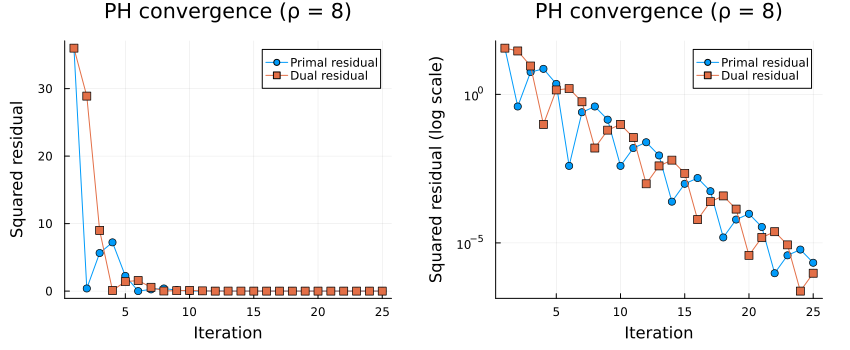

In [29]:
# Plotting code for Question 3
# Assumes: rp2, rd2  (primal/dual residual vectors from run_PH_2stage)

ε = 1e-12
iters = 1:length(rp2)

p_lin = plot(iters, rp2, label="Primal residual", marker=:circle,
    xlabel="Iteration", ylabel="Squared residual",
    title="PH convergence (ρ = 8)", legend=:topright)
plot!(p_lin, iters, rd2, label="Dual residual", marker=:square)

p_log = plot(iters, max.(rp2, ε), label="Primal residual", marker=:circle,
    yscale=:log10, xlabel="Iteration", ylabel="Squared residual (log scale)",
    title="PH convergence (ρ = 8)", legend=:topright)
plot!(p_log, iters, max.(rd2, ε), label="Dual residual", marker=:square)

plot(p_lin, p_log, layout=(1,2), size=(850,350), margin=5Plots.mm)

## Question 4 — Sensitivity to the penalty parameter

Repeat the experiment of Question 3 using $\rho \in \{1, 25, 100\}$.
Plot the primal and dual residuals against iteration count and discuss:

- How does a **small** $\rho$ affect the balance between primal and dual residuals
  and overall convergence speed?
- How does a **large** $\rho$ affect the same?
- What trade-off does $\rho$ encode, recalling that it acts both as a penalty coefficient
  and as a step size in the $\lambda$-update?

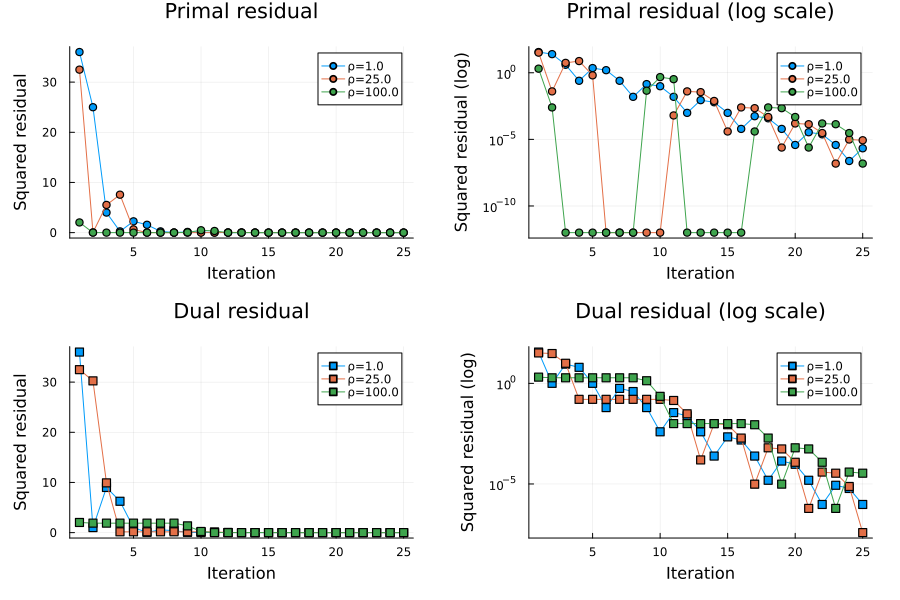

In [30]:
# Plotting code for Question 4
# Assumes: rho_vals defined above; run_PH_2stage returns (xs, z, lam, r_prim, r_dual)

rho_vals = [1.0, 25.0, 100.0]
ε = 1e-12

p_prim_lin = plot(title="Primal residual",            xlabel="Iteration", ylabel="Squared residual",       legend=:topright)
p_prim_log = plot(title="Primal residual (log scale)", xlabel="Iteration", ylabel="Squared residual (log)", legend=:topright)
p_dual_lin = plot(title="Dual residual",               xlabel="Iteration", ylabel="Squared residual",       legend=:topright)
p_dual_log = plot(title="Dual residual (log scale)",   xlabel="Iteration", ylabel="Squared residual (log)", legend=:topright)

for rho_val in rho_vals
    _, _, _, rp, rd = run_PH_2stage(rho_val, verbose=false)
    plot!(p_prim_lin, 1:length(rp), rp,          label="ρ=$rho_val", marker=:circle)
    plot!(p_prim_log, 1:length(rp), max.(rp, ε), label="ρ=$rho_val", marker=:circle)
    plot!(p_dual_lin, 1:length(rd), rd,          label="ρ=$rho_val", marker=:square)
    plot!(p_dual_log, 1:length(rd), max.(rd, ε), label="ρ=$rho_val", marker=:square)
end

plot!(p_prim_log, yscale=:log10)
plot!(p_dual_log, yscale=:log10)
plot(p_prim_lin, p_prim_log, p_dual_lin, p_dual_log,
    layout=(2,2), size=(900,600), margin=5Plots.mm)

## Question 5 — Three-stage progressive hedging

Extend the problem to three stages. The operator decides a baseline investment $x^1 \ge 0$ before any information is revealed, then may install additional capacity $x^2_n \ge 0$ at cost $c_2 = 18$ after observing the stage-2 node. Dispatch in periods 2–4 proceeds as before under full information.

### (a) Node structure

Identify the bundles $S(n_L)$ and $S(n_H)$, their probabilities, and the
nonanticipativity constraints at each stage.

---

### (b) z-update formulas

Write out the $z$-update expressions for $z^1$ and $z^2_n$ using the conditional
weights $w^t_{s,n} = P_s / P_n$.

---

### (c) Implementation

In [ ]:
# Node structure for the 3-stage extension
# Low node nL: d[2,s] = 3  for s in {1,2,3}
# High node nH: d[2,s] = 20 for s in {4,5,6}
bundle  = Dict(:nL => [1,2,3], :nH => [4,5,6])
node_of = Dict(1=>:nL, 2=>:nL, 3=>:nL, 4=>:nH, 5=>:nH, 6=>:nH)
P_node  = Dict(:nL => 0.5, :nH => 0.5)
nodes   = [:nL, :nH]

# Precomputed conditional weights  w[s,n] = P[s] / P_node[n]
# (used in the z-update for stage 2)
w = Dict((s,n) => P[s] / P_node[n] for (n,bs) in bundle for s in bs)

println("\nConditional weights w[s,n]:")
for (k,v) in sort(collect(w), by=first)
    @printf("  w%s = %.4f\n", k, v)
end

In [ ]:
function solve_subproblem_3stage(s, lam1s, z1, lam2s, z2_val, rho)
    m = Model(Gurobi_constructor)
    set_silent(m)

    # Stage-1 and stage-2 capacity copies for this scenario
    @variable(m, x1 >= 0)
    @variable(m, x2 >= 0)
    # Dispatch variables
    @variable(m, cvar[T] >= 0)  # charge
    @variable(m, u[T]    >= 0)  # discharge
    @variable(m, e[T]    >= 0)  # stored energy
    @variable(m, y[T]    >= 0)  # backup

    # TODO: write the augmented Lagrangian objective
    #   Include investment + dual + penalty terms for BOTH x1 and x2:
    #     stage-1 block: c_inv*x1 + lam1s*x1 + (rho/2)*(x1-z1)^2  (constant -lam1s*z1 dropped)
    #     stage-2 block: c2*x2   + lam2s*x2 + (rho/2)*(x2-z2_val)^2  (constant dropped)
    #   Plus the dispatch cost for scenario s


    # TODO: energy balance constraints (same as before)

    # TODO: storage capacity constraints
    #   Hint: total available capacity for scenario s is x1 + x2

    # TODO: charge rate and demand satisfaction constraints


    optimize!(m)
    return value(x1), value(x2)
end

In [ ]:
function run_PH_3stage(rho_val; n_iter=25, verbose=true)
    nS = length(S)

    # TODO: initialise lam1 and lam2 (vectors of zeros over scenarios)
    # TODO: initialise z1 = 0.0 and z2 as a Dict over nodes (both 0.0)
    # TODO: initialise x1v and x2v (vectors of zeros)
    # TODO: initialise residual vectors rp1, rp2_v, rd1, rd2_v

    if verbose
        println("ρ = $rho_val  (3-stage)")
        println("Iter |   z1      z2_L    z2_H  | rp_stage1  rp_stage2")
        println("-----+-------------------------+---------------------")
    end

    for k in 1:n_iter
        # TODO: save z1_prev and z2_prev for dual residuals

        # Step 1 — x-update
        # Hint: use node_of[s] to look up the correct z2 value for each scenario
        # TODO

        # Step 2 — z-update
        # z1: probability-weighted average over all scenarios
        # z2[n]: conditional-weight average over bundle[n]  (use precomputed w)
        # TODO

        # TODO: compute stage-1 primal residual: sum_s P[s]*(x1v[s]-z1)^2
        # TODO: compute stage-2 primal residual: sum_s P[s]*(x2v[s]-z2[node_of[s]])^2
        # TODO: compute stage-1 and stage-2 dual residuals analogously
        # TODO: append all four residuals to their vectors

        # Step 3 — lambda-update for both stages
        # TODO

        if verbose
            # TODO: print iteration summary using @printf
        end
    end

    return x1v, x2v, z1, z2, rp1, rp2_v, rd1, rd2_v
end

x1_3s, x2_3s, z1_3s, z2_3s, rp1_3s, rp2_3s, rd1_3s, rd2_3s =
    run_PH_3stage(8.0)

In [ ]:
# Plotting code for Question 5
# Assumes: rp1_3s, rp2_3s, rd1_3s, rd2_3s  (residual vectors from run_PH_3stage)

ε = 1e-12
iters3 = 1:length(rp1_3s)

p_lin = plot(iters3, rp1_3s, label="Stage 1 primal", marker=:circle,
    xlabel="Iteration", ylabel="Squared residual",
    title="3-stage PH convergence (ρ = 8)", legend=:topright)
plot!(p_lin, iters3, rp2_3s, label="Stage 2 primal", marker=:square)
plot!(p_lin, iters3, rd1_3s, label="Stage 1 dual",   marker=:diamond,   linestyle=:dash)
plot!(p_lin, iters3, rd2_3s, label="Stage 2 dual",   marker=:utriangle, linestyle=:dash)

p_log = plot(iters3, max.(rp1_3s, ε), label="Stage 1 primal", marker=:circle,
    yscale=:log10, xlabel="Iteration", ylabel="Squared residual (log scale)",
    title="3-stage PH convergence (ρ = 8)", legend=:topright)
plot!(p_log, iters3, max.(rp2_3s, ε), label="Stage 2 primal", marker=:square)
plot!(p_log, iters3, max.(rd1_3s, ε), label="Stage 1 dual",   marker=:diamond,   linestyle=:dash)
plot!(p_log, iters3, max.(rd2_3s, ε), label="Stage 2 dual",   marker=:utriangle, linestyle=:dash)

plot(p_lin, p_log, layout=(1,2), size=(900,400), margin=5Plots.mm)